In [2]:
import pandas as pd

In [3]:
import numpy as np

In [4]:
store_df = pd.read_csv("D:/projects/Final Project/SmartRetail Insights/data/store.csv")
train_df = pd.read_csv("D:/projects/Final Project/SmartRetail Insights/data/train.csv", parse_dates=['Date'])

C:\Users\cw\AppData\Local\Temp\ipykernel_13528\2671224165.py:2: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv("D:/projects/Final Project/SmartRetail Insights/data/train.csv", parse_dates=['Date'])


In [5]:
df = pd.merge(train_df, store_df, on='Store', how='left')

In [6]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [7]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['WeekOfYear'] = df['Date'].dt.isocalendar().week
df['DayOfWeek'] = df['Date'].dt.dayofweek  # 0=Mon, 6=Sun
df['IsWeekend'] = df['DayOfWeek'].isin([5,6]).astype(int)


In [8]:
categorical_cols = ['StoreType', 'Assortment','PromoInterval']
df[categorical_cols] = df[categorical_cols].fillna('None')
df = pd.get_dummies(df, columns=categorical_cols)


In [9]:
df = df[(df['Open'] == 1) & (df['Sales'] > 0)]

In [10]:
X = df.drop(['Sales', 'Customers', 'Date'], axis=1)
y = df['Sales']

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
# pip install lightgbm

In [13]:
df.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'CompetitionDistance',
       'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2',
       'Promo2SinceWeek', 'Promo2SinceYear', 'Year', 'Month', 'Day',
       'WeekOfYear', 'IsWeekend', 'StoreType_a', 'StoreType_b', 'StoreType_c',
       'StoreType_d', 'Assortment_a', 'Assortment_b', 'Assortment_c',
       'PromoInterval_Feb,May,Aug,Nov', 'PromoInterval_Jan,Apr,Jul,Oct',
       'PromoInterval_Mar,Jun,Sept,Dec', 'PromoInterval_None'],
      dtype='object')

In [14]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,CompetitionDistance,...,StoreType_b,StoreType_c,StoreType_d,Assortment_a,Assortment_b,Assortment_c,"PromoInterval_Feb,May,Aug,Nov","PromoInterval_Jan,Apr,Jul,Oct","PromoInterval_Mar,Jun,Sept,Dec",PromoInterval_None
0,1,4,2015-07-31,5263,555,1,1,0,1,1270.0,...,False,True,False,True,False,False,False,False,False,True
1,2,4,2015-07-31,6064,625,1,1,0,1,570.0,...,False,False,False,True,False,False,False,True,False,False
2,3,4,2015-07-31,8314,821,1,1,0,1,14130.0,...,False,False,False,True,False,False,False,True,False,False
3,4,4,2015-07-31,13995,1498,1,1,0,1,620.0,...,False,True,False,False,False,True,False,False,False,True
4,5,4,2015-07-31,4822,559,1,1,0,1,29910.0,...,False,False,False,True,False,False,False,False,False,True


In [15]:
df.dtypes

Store                                      int64
DayOfWeek                                  int32
Date                              datetime64[ns]
Sales                                      int64
Customers                                  int64
Open                                       int64
Promo                                      int64
StateHoliday                              object
SchoolHoliday                              int64
CompetitionDistance                      float64
CompetitionOpenSinceMonth                float64
CompetitionOpenSinceYear                 float64
Promo2                                     int64
Promo2SinceWeek                          float64
Promo2SinceYear                          float64
Year                                       int32
Month                                      int32
Day                                        int32
WeekOfYear                                UInt32
IsWeekend                                  int64
StoreType_a         

In [16]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import joblib
import pandas as pd

# Dummy data
X, y = make_regression(n_samples=100, n_features=30)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('regressor', LinearRegression())
])

pipeline.fit(X_train, y_train)

print(type(pipeline))   # <class 'sklearn.pipeline.Pipeline'>
print(pipeline.get_params())  # ✅ Should not fail

joblib.dump(pipeline, 'sales_forecast_model.pkl')

<class 'sklearn.pipeline.Pipeline'>
{'memory': None, 'steps': [('imputer', SimpleImputer()), ('regressor', LinearRegression())], 'verbose': False, 'imputer': SimpleImputer(), 'regressor': LinearRegression(), 'imputer__add_indicator': False, 'imputer__copy': True, 'imputer__fill_value': None, 'imputer__keep_empty_features': False, 'imputer__missing_values': nan, 'imputer__strategy': 'mean', 'regressor__copy_X': True, 'regressor__fit_intercept': True, 'regressor__n_jobs': None, 'regressor__positive': False}


['sales_forecast_model.pkl']

In [20]:
# Test load
model = joblib.load('sales_forecast_model.pkl')
print(type(model))  # Should be Pipeline
print(model.get_params())  # ✅ Should not fail

<class 'sklearn.pipeline.Pipeline'>
{'memory': None, 'steps': [('imputer', SimpleImputer()), ('regressor', LinearRegression())], 'verbose': False, 'imputer': SimpleImputer(), 'regressor': LinearRegression(), 'imputer__add_indicator': False, 'imputer__copy': True, 'imputer__fill_value': None, 'imputer__keep_empty_features': False, 'imputer__missing_values': nan, 'imputer__strategy': 'mean', 'regressor__copy_X': True, 'regressor__fit_intercept': True, 'regressor__n_jobs': None, 'regressor__positive': False}


In [18]:
# X_train = X_train.fillna(0)
# y_train = y_train.fillna(0)

In [19]:
print(X_train.isnull().sum())
print(y_train.isnull().sum())

AttributeError: 'numpy.ndarray' object has no attribute 'isnull'

In [ ]:
# # Drop raw categorical cols after one-hot encoding
# df = df.drop(['StateHoliday', 'StoreType', 'Assortment', 'PromoInterval'], axis=1, errors='ignore')

# # Confirm only numeric types
# print(df.dtypes[df.dtypes == 'object'])

# # Train-test split (repeat if necessary)
# X = df.drop(['Sales', 'Date', 'Customers'], axis=1, errors='ignore')
# y = df['Sales']

# from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
model = joblib.load("sales_forecast_model.pkl")
print(type(model))  

<class 'lightgbm.sklearn.LGBMRegressor'>


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Predictions
preds = model.predict(X_test)

# Evaluation metrics
print("RMSE:", mean_squared_error(y_test, preds, squared=False))
print("MAE:", mean_absolute_error(y_test, preds))
print("R² Score:", r2_score(y_test, preds))

ValueError: pandas dtypes must be int, float or bool.
Fields with bad pandas dtypes: StateHoliday: object

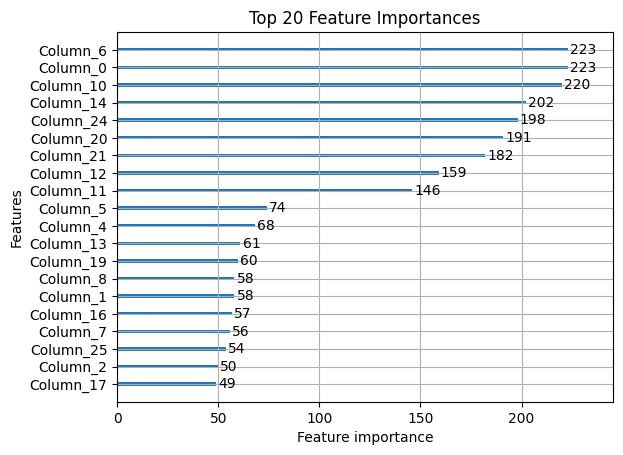

In [ ]:
import matplotlib.pyplot as plt
import lightgbm as lgb

lgb.plot_importance(model, max_num_features=20)
plt.title("Top 20 Feature Importances")
plt.show()


In [ ]:
import joblib
import pandas as pd

model = joblib.load('sales_forecast_model.pkl')

print(type(model))

df = pd.DataFrame([{
  "Store": 1,
  "DayOfWeek": 4,
  "Open": 1,
  "Promo": 1,
  "SchoolHoliday": 0,
  "CompetitionDistance": 200.0,
  "CompetitionOpenSinceMonth": 9,
  "CompetitionOpenSinceYear": 2010,
  "Promo2": 1,
  "Promo2SinceWeek": 13,
  "Promo2SinceYear": 2015,
  "Year": 2022,
  "Month": 1,
  "Day": 1,
  "WeekOfYear": 1,
  "IsWeekend": 0,
  "StoreType_a": 1,
  "StoreType_b": 0,
  "StoreType_c": 0,
  "StoreType_d": 0,
  "Assortment_a": 1,
  "Assortment_b": 0,
  "Assortment_c": 0,
  "PromoInterval_Feb_May_Aug_Nov": 0,
  "PromoInterval_Jan_Apr_Jul_Oct": 1,
  "PromoInterval_Mar_Jun_Sept_Dec": 0,
  "PromoInterval_None": 0
}])

print(df.columns.tolist())
print(df.shape)

pred = model.predict(df)
print(pred)

<class 'lightgbm.sklearn.LGBMRegressor'>
['Store', 'DayOfWeek', 'Open', 'Promo', 'SchoolHoliday', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'Year', 'Month', 'Day', 'WeekOfYear', 'IsWeekend', 'StoreType_a', 'StoreType_b', 'StoreType_c', 'StoreType_d', 'Assortment_a', 'Assortment_b', 'Assortment_c', 'PromoInterval_Feb_May_Aug_Nov', 'PromoInterval_Jan_Apr_Jul_Oct', 'PromoInterval_Mar_Jun_Sept_Dec', 'PromoInterval_None']
(1, 27)


LightGBMError: The number of features in data (27) is not the same as it was in training data (30).
You can set ``predict_disable_shape_check=true`` to discard this error, but please be aware what you are doing.

In [ ]:
print("Number of features expected by the model:", len(model_features))

Number of features expected by the model: 27


In [ ]:
print("Model expects the following 27 features:")
for i, feat in enumerate(model_features, 1):
    print(f"{i}. {feat}")

Model expects the following 27 features:
1. Store
2. DayOfWeek
3. Open
4. Promo
5. SchoolHoliday
6. CompetitionDistance
7. CompetitionOpenSinceMonth
8. CompetitionOpenSinceYear
9. Promo2
10. Promo2SinceWeek
11. Promo2SinceYear
12. Year
13. Month
14. Day
15. WeekOfYear
16. IsWeekend
17. StoreType_a
18. StoreType_b
19. StoreType_c
20. StoreType_d
21. Assortment_a
22. Assortment_b
23. Assortment_c
24. PromoInterval_Feb_May_Aug_Nov
25. PromoInterval_Jan_Apr_Jul_Oct
26. PromoInterval_Mar_Jun_Sept_Dec
27. PromoInterval_None


In [ ]:
import joblib
import pandas as pd

model = joblib.load('D:/projects/Final Project/SmartRetail Insights/backend/models/sales_forecast_model.pkl')

sample_input = {
    'Store': 1,
    'DayOfWeek': 4,
    'Open': 1,
    'Promo': 1,
    'SchoolHoliday': 0,
    'CompetitionDistance': 200.0,
    'CompetitionOpenSinceMonth': 9,
    'CompetitionOpenSinceYear': 2010,
    'Promo2': 1,
    'Promo2SinceWeek': 13,
    'Promo2SinceYear': 2015,
    'Year': 2022,
    'Month': 1,
    'Day': 1,
    'WeekOfYear': 1,
    'IsWeekend': 0,
    'StoreType_a': 1,
    'StoreType_b': 0,
    'StoreType_c': 0,
    'StoreType_d': 0,
    'Assortment_a': 1,
    'Assortment_b': 0,
    'Assortment_c': 0,
    'PromoInterval_Feb_May_Aug_Nov': 0,
    'PromoInterval_Jan_Apr_Jul_Oct': 1,
    'PromoInterval_Mar_Jun_Sept_Dec': 0,
    'PromoInterval_None': 0
}

df = pd.DataFrame([sample_input])
print("Predicting with shape:", df.shape)

prediction = model.predict(df)
print("Prediction result:", prediction)

Predicting with shape: (1, 27)
Prediction result: [8390.55416996]


In [ ]:
print("Model type:", type(model))

Model type: <class 'lightgbm.sklearn.LGBMRegressor'>


In [ ]:
# !pip install xgboost

In [ ]:
model = joblib.load('D:/projects/Final Project/SmartRetail Insights/backend/models/sales_forecast_model.pkl')

print(type(model))
print(model)

<class 'lightgbm.sklearn.LGBMRegressor'>
LGBMRegressor()


In [ ]:
print(model.feature_name_)

['Column_0', 'Column_1', 'Column_2', 'Column_3', 'Column_4', 'Column_5', 'Column_6', 'Column_7', 'Column_8', 'Column_9', 'Column_10', 'Column_11', 'Column_12', 'Column_13', 'Column_14', 'Column_15', 'Column_16', 'Column_17', 'Column_18', 'Column_19', 'Column_20', 'Column_21', 'Column_22', 'Column_23', 'Column_24', 'Column_25', 'Column_26', 'Column_27', 'Column_28', 'Column_29']
